**Exploratory Data Analysis**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the datasets
daily_orders = pd.read_csv('daily_orders_2024_2025.csv')
weekly_features = pd.read_csv('weekly_features_2024_2025.csv')

print("--- Daily Orders Info ---")
print(daily_orders.info())
print("\n--- Daily Orders Head ---")
print(daily_orders.head())

print("\n--- Weekly Features Info ---")
print(weekly_features.info())
print("\n--- Weekly Features Head ---")
print(weekly_features.head())

--- Daily Orders Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7310 entries, 0 to 7309
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   company         7310 non-null   str  
 1   date            7310 non-null   str  
 2   order_count     7310 non-null   int64
 3   canceled_count  7310 non-null   int64
dtypes: int64(2), str(2)
memory usage: 228.6 KB
None

--- Daily Orders Head ---
     company        date  order_count  canceled_count
0  Company_B  2024-01-01         7854             282
1  Company_B  2024-01-02         3802             128
2  Company_B  2024-01-03         3676             109
3  Company_B  2024-01-04         3457              94
4  Company_B  2024-01-05         3554             111

--- Weekly Features Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   ---------

In [3]:
print("Unique companies in daily:", daily_orders['company'].unique())
print("Unique companies in weekly:", weekly_features['company'].unique())
print("Date range in daily:", daily_orders['date'].min(), "to", daily_orders['date'].max())
print("Week start range in weekly:", weekly_features['week_start'].min(), "to", weekly_features['week_start'].max())

Unique companies in daily: <StringArray>
['Company_B', 'Company_C', 'Company_H', 'Company_G', 'Company_J', 'Company_A',
 'Company_D', 'Company_I', 'Company_F', 'Company_E']
Length: 10, dtype: str
Unique companies in weekly: <StringArray>
['Company_B', 'Company_C', 'Company_H', 'Company_G', 'Company_J', 'Company_A',
 'Company_D', 'Company_I', 'Company_F', 'Company_E']
Length: 10, dtype: str
Date range in daily: 2024-01-01 to 2025-12-31
Week start range in weekly: 2024-01-01 to 2025-12-29


Time-Serries & Seasonality Analysis

In [4]:
# Time-Series & Seasonality Analysis
daily_orders['date'] = pd.to_datetime(daily_orders['date'])
weekly_features['week_start'] = pd.to_datetime(weekly_features['week_start'])

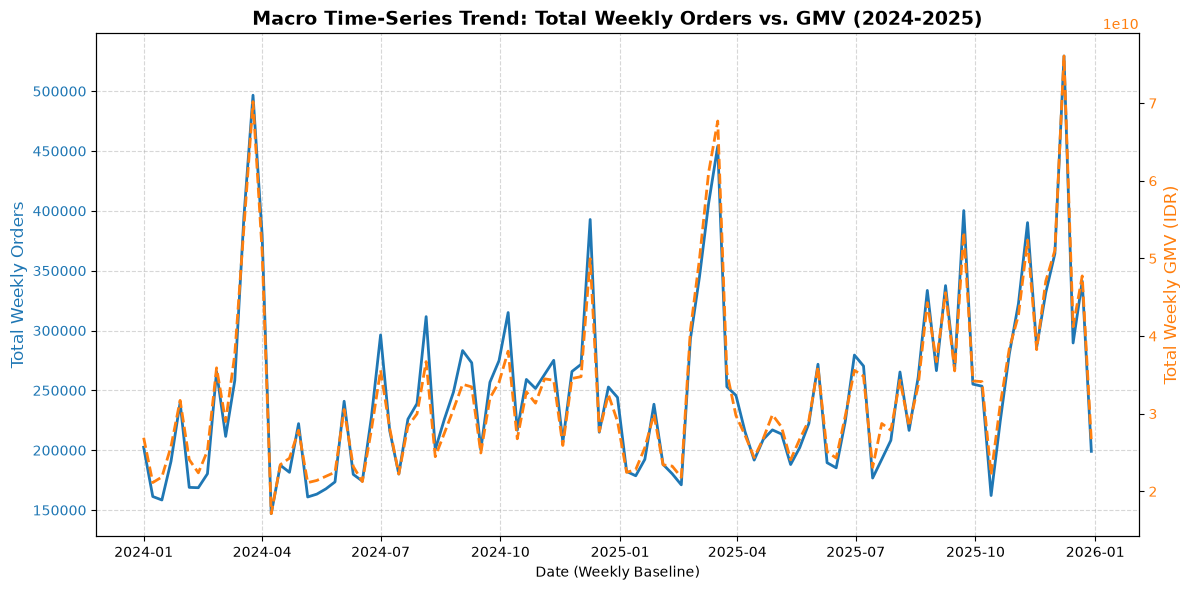

In [5]:
# Macro Time-Series Trend (Orders vs GMV)
weekly_macro = weekly_features.groupby('week_start')[['orders', 'gmv_idr']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotting Total Orders on Left Y-Axis
color = 'tab:blue'
ax1.set_xlabel('Date (Weekly Baseline)')
ax1.set_ylabel('Total Weekly Orders', color=color, fontsize=12)
ax1.plot(weekly_macro['week_start'], weekly_macro['orders'], color=color, linewidth=2, label='Total Orders')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Plotting Total GMV on Right Y-Axis (using twinx)
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Total Weekly GMV (IDR)', color=color, fontsize=12)
ax2.plot(weekly_macro['week_start'], weekly_macro['gmv_idr'], color=color, linewidth=2, linestyle='--', label='Total GMV')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Macro Time-Series Trend: Total Weekly Orders vs. GMV (2024-2025)', fontsize=14, fontweight='bold')
fig.tight_layout()
# plt.saves

C:\Users\mrfirdaus\AppData\Local\Temp\ipykernel_27468\3072518937.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dow_analysis, x='day_of_week', y='order_count', palette='Blues_d')


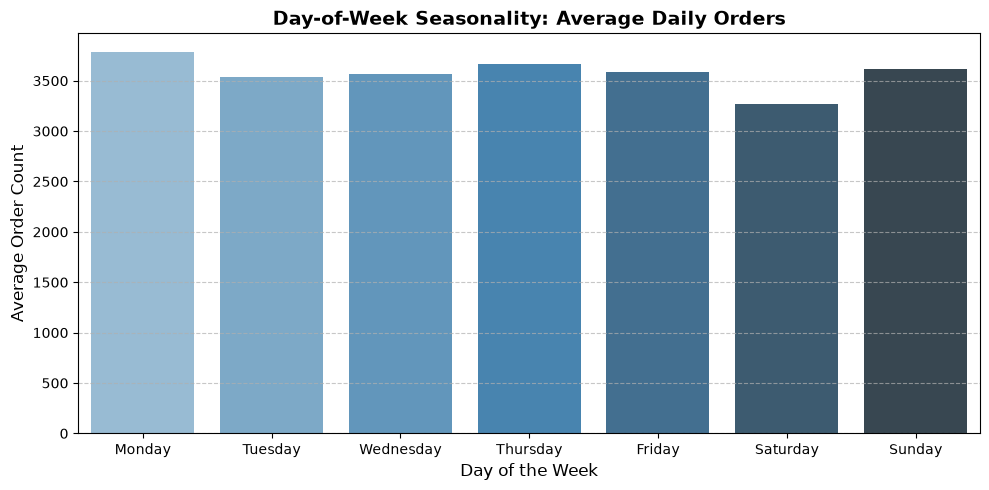

In [6]:
# Day-of-Week Seasonality
daily_orders['day_of_week'] = daily_orders['date'].dt.day_name()
daily_orders['day_of_week_num'] = daily_orders['date'].dt.dayofweek

# Sort by chronological day index
dow_analysis = daily_orders.groupby(['day_of_week_num', 'day_of_week'])['order_count'].mean().reset_index()

plt.subplots(figsize=(10, 5))
sns.barplot(data=dow_analysis, x='day_of_week', y='order_count', palette='Blues_d')
plt.title('Day-of-Week Seasonality: Average Daily Orders', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Order Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('day_of_week_seasonality.png', dpi=300)
# plt.close()

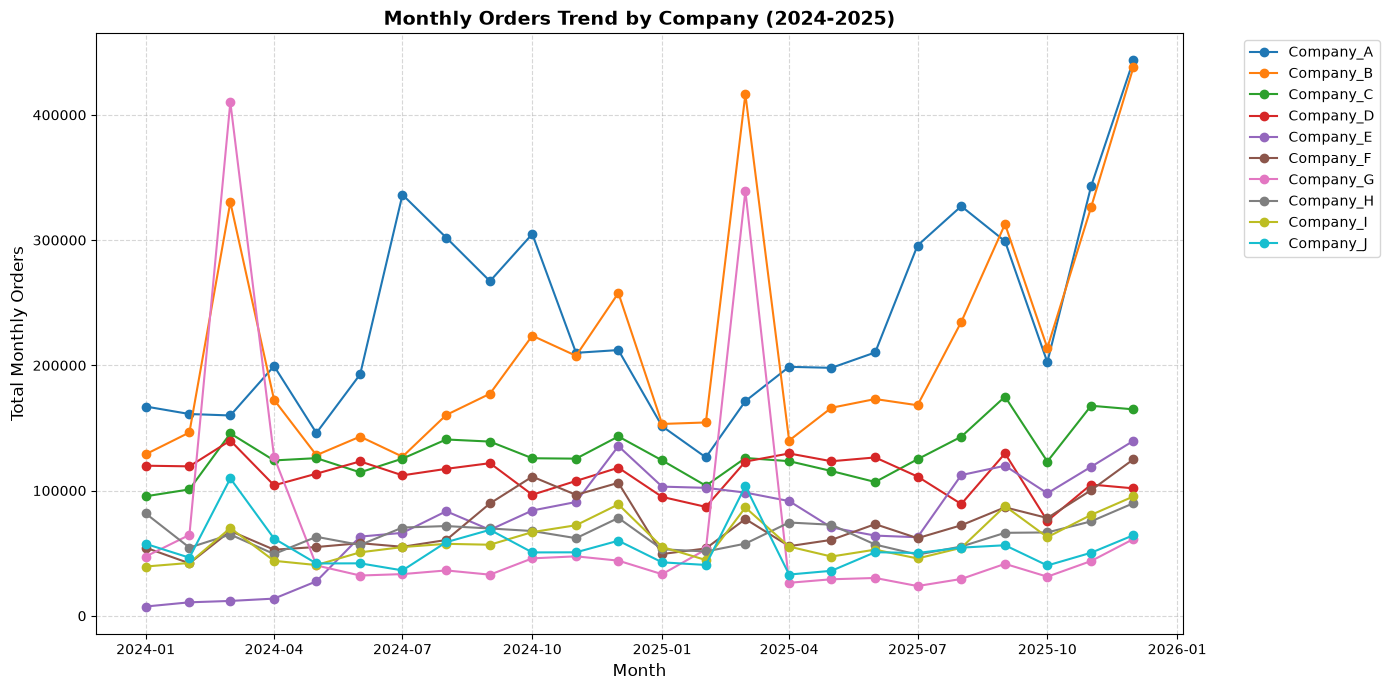

In [7]:
# Monthly Breakdown Trends by Company
daily_orders['month'] = daily_orders['date'].dt.to_period('M')
monthly_company = daily_orders.groupby(['month', 'company'])['order_count'].sum().reset_index()
monthly_company['month'] = monthly_company['month'].dt.to_timestamp()

plt.subplots(figsize=(14, 7))
for company in sorted(monthly_company['company'].unique()):
    comp_data = monthly_company[monthly_company['company'] == company]
    plt.plot(comp_data['month'], comp_data['order_count'], marker='o', label=company)

plt.title('Monthly Orders Trend by Company (2024-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Monthly Orders', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('monthly_trend_by_company.png', dpi=300)
# plt.close()

Comparative & Categorical Analysis

C:\Users\mrfirdaus\AppData\Local\Temp\ipykernel_27468\3982409727.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(company_gmv_sorted['company'], rotation=45)


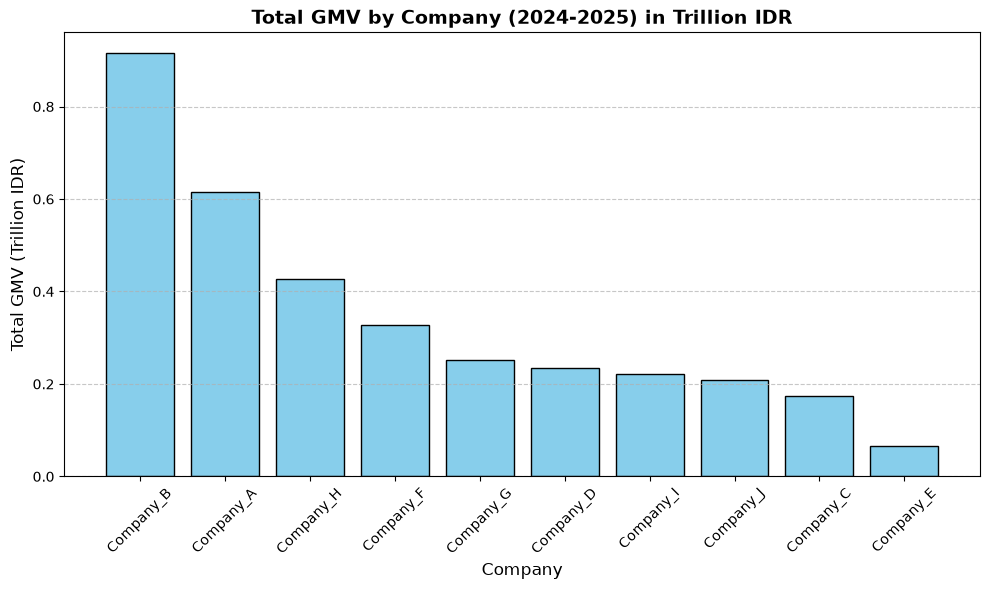

In [8]:
# Total GMV by Company (Sorted Bar Chart)
company_gmv = weekly_features.groupby('company')['gmv_idr'].sum().reset_index()
company_gmv_sorted = company_gmv.sort_values(by='gmv_idr', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(company_gmv_sorted['company'], company_gmv_sorted['gmv_idr'] / 1e12, color='skyblue', edgecolor='black')
ax.set_title('Total GMV by Company (2024-2025) in Trillion IDR', fontsize=14, fontweight='bold')
ax.set_xlabel('Company', fontsize=12)
ax.set_ylabel('Total GMV (Trillion IDR)', fontsize=12)
ax.set_xticklabels(company_gmv_sorted['company'], rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('company_total_gmv.png', dpi=300)
# plt.close()

C:\Users\mrfirdaus\AppData\Local\Temp\ipykernel_27468\2932586958.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=weekly_features, x='company', y='orders', order=company_order_median, ax=ax, palette='Set3')
C:\Users\mrfirdaus\AppData\Local\Temp\ipykernel_27468\2932586958.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


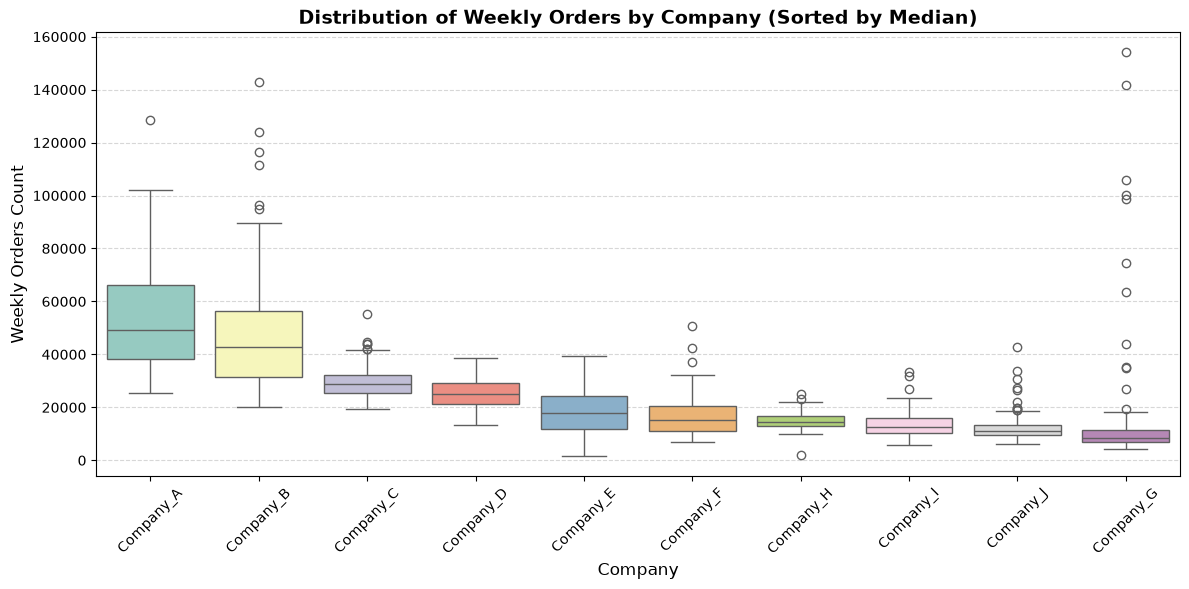

In [9]:
# Distribution of Weekly Orders by Company
company_order_median = weekly_features.groupby('company')['orders'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=weekly_features, x='company', y='orders', order=company_order_median, ax=ax, palette='Set3')
ax.set_title('Distribution of Weekly Orders by Company (Sorted by Median)', fontsize=14, fontweight='bold')
ax.set_xlabel('Company', fontsize=12)
ax.set_ylabel('Weekly Orders Count', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('company_orders_distribution.png', dpi=300)
# plt.close()

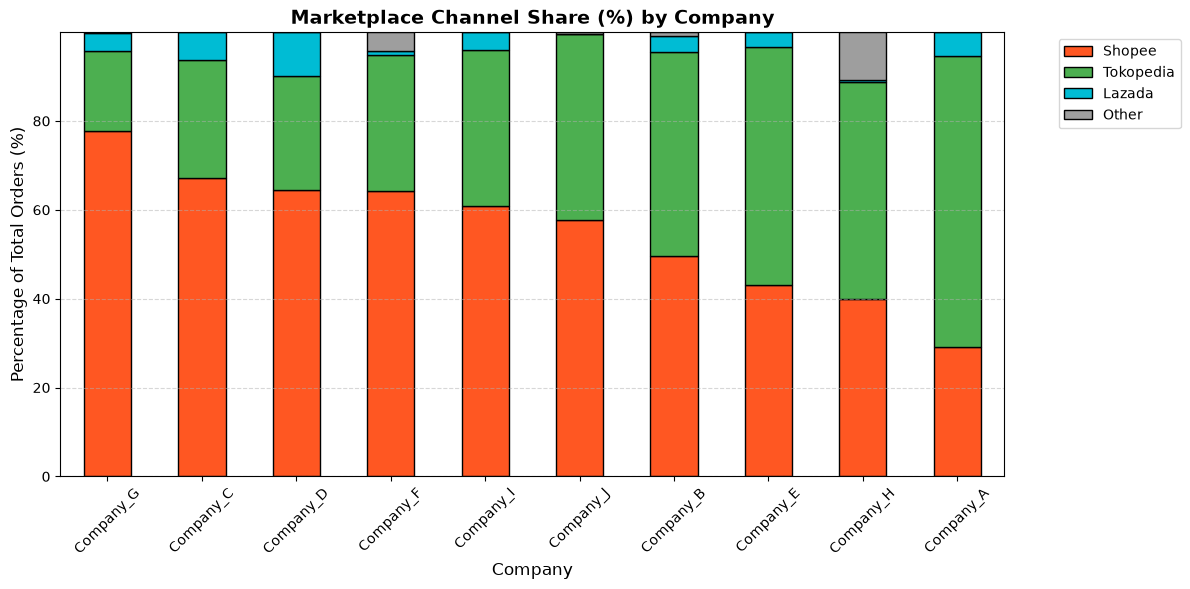

In [10]:
# Marketplace Breakdown (Channel Share) per Company
channels = ['orders_shopee', 'orders_tokopedia', 'orders_lazada', 'orders_other']
company_channels = weekly_features.groupby('company')[channels].sum()
# Convert to percentages
company_channels_pct = company_channels.div(company_channels.sum(axis=1), axis=0) * 100
# Sort companies by total orders to keep an ordered flow, or alphabetically. Let's sort by total Shopee percentage for order.
company_channels_pct = company_channels_pct.sort_values(by='orders_shopee', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
company_channels_pct.plot(kind='bar', stacked=True, ax=ax, color=['#FF5722', '#4CAF50', '#00BCD4', '#9E9E9E'], edgecolor='black')
ax.set_title('Marketplace Channel Share (%) by Company', fontsize=14, fontweight='bold')
ax.set_xlabel('Company', fontsize=12)
ax.set_ylabel('Percentage of Total Orders (%)', fontsize=12)
ax.legend(['Shopee', 'Tokopedia', 'Lazada', 'Other'], bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('company_marketplace_share.png', dpi=300)
# plt.close()

Ratio & Efficiency Analysis

In [11]:
# Feature Engineering (Calculating Business Efficiency Ratios)
weekly_features['cancellation_rate'] = weekly_features['canceled'] / weekly_features['orders']
weekly_features['aov_idr'] = weekly_features['gmv_idr'] / weekly_features['orders']
weekly_features['cod_ratio'] = weekly_features['cod_orders'] / weekly_features['orders']
weekly_features['items_per_order'] = weekly_features['total_qty'] / weekly_features['orders']

In [12]:
# Group by company to get overall efficiency baselines
company_efficiency = weekly_features.groupby('company')[['cancellation_rate', 'aov_idr', 'cod_ratio', 'items_per_order']].mean().reset_index()

C:\Users\mrfirdaus\AppData\Local\Temp\ipykernel_27468\2284959715.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(company_efficiency_sorted_aov['company'], rotation=45)


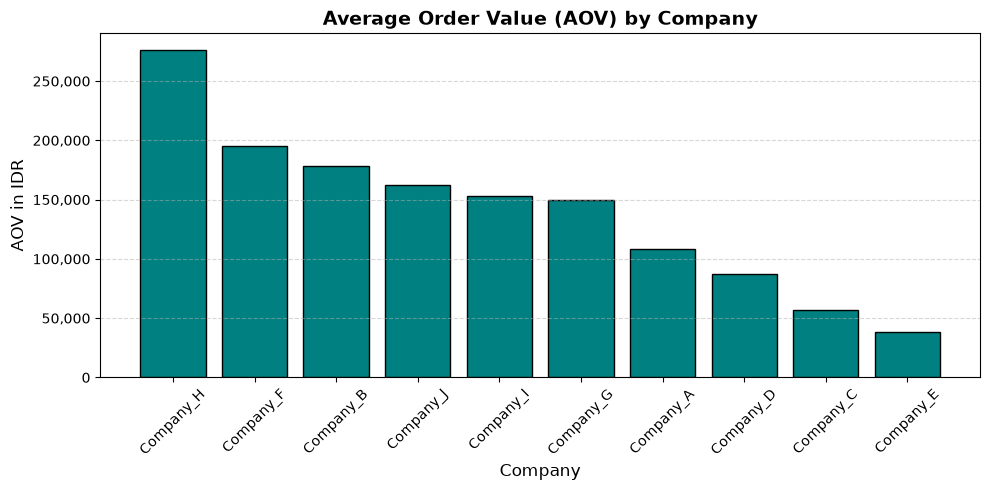

In [13]:
# Average Order Value (AOV) by Company
company_efficiency_sorted_aov = company_efficiency.sort_values(by='aov_idr', ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(company_efficiency_sorted_aov['company'], company_efficiency_sorted_aov['aov_idr'], color='teal', edgecolor='black')
ax.set_title('Average Order Value (AOV) by Company', fontsize=14, fontweight='bold')
ax.set_xlabel('Company', fontsize=12)
ax.set_ylabel('AOV in IDR', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_xticklabels(company_efficiency_sorted_aov['company'], rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('company_aov.png', dpi=300)
# plt.close()

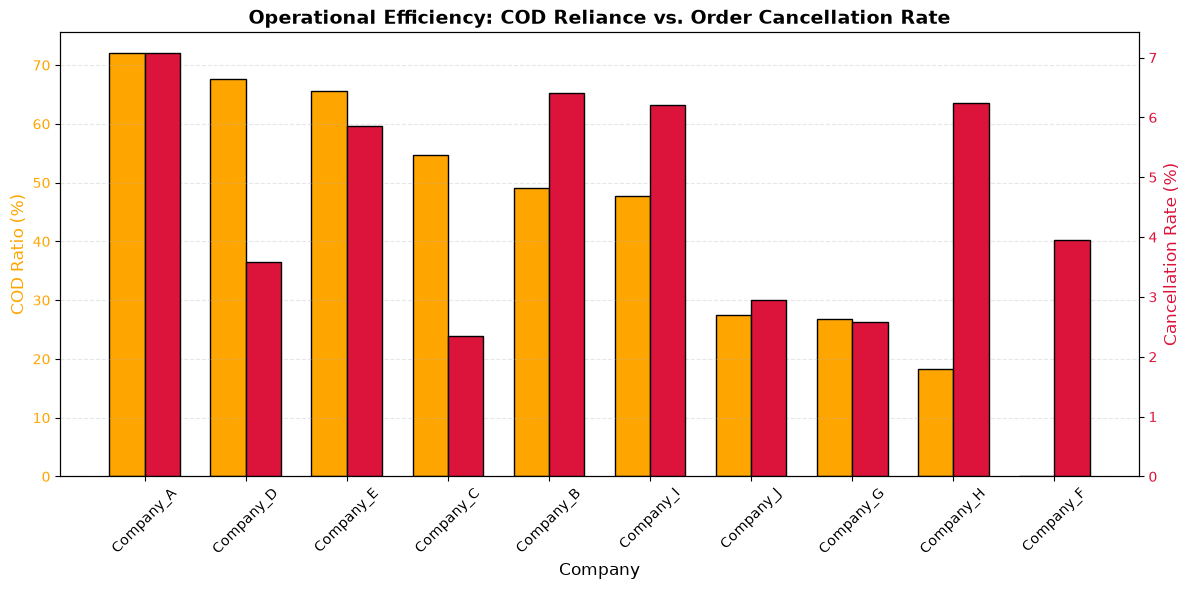

In [14]:
# Dual-Axis Chart: COD Reliance vs. Cancellation Rate
company_efficiency_sorted_cod = company_efficiency.sort_values(by='cod_ratio', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))
x = range(len(company_efficiency_sorted_cod))
width = 0.35

# COD Bar (Left Axis)
rects1 = ax1.bar([i - width/2 for i in x], company_efficiency_sorted_cod['cod_ratio'] * 100, width, label='COD Ratio (%)', color='orange', edgecolor='black')
ax1.set_xlabel('Company', fontsize=12)
ax1.set_ylabel('COD Ratio (%)', color='orange', fontsize=12)
ax1.tick_params(axis='y', labelcolor='orange')
ax1.set_xticks(x)
ax1.set_xticklabels(company_efficiency_sorted_cod['company'], rotation=45)

# Cancellation Bar (Right Axis)
ax2 = ax1.twinx()
rects2 = ax2.bar([i + width/2 for i in x], company_efficiency_sorted_cod['cancellation_rate'] * 100, width, label='Cancellation Rate (%)', color='crimson', edgecolor='black')
ax2.set_ylabel('Cancellation Rate (%)', color='crimson', fontsize=12)
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('Operational Efficiency: COD Reliance vs. Order Cancellation Rate', fontsize=14, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)
fig.tight_layout()
# plt.savefig('cod_vs_cancellation.png', dpi=300)
# plt.close()

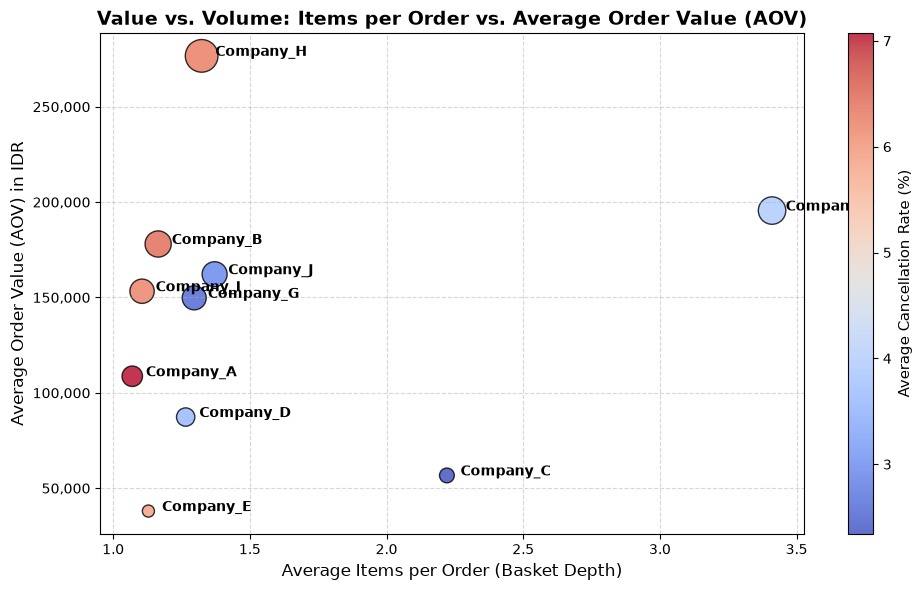

In [15]:
# Value vs. Volume Scatter Profile
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(company_efficiency['items_per_order'], company_efficiency['aov_idr'], 
                     s=company_efficiency['aov_idr']/500, c=company_efficiency['cancellation_rate']*100, 
                     cmap='coolwarm', alpha=0.8, edgecolors='black')

# Annotate points with company names
for i, row in company_efficiency.iterrows():
    ax.text(row['items_per_order'] + 0.05, row['aov_idr'], row['company'], fontsize=10, fontweight='bold')

ax.set_title('Value vs. Volume: Items per Order vs. Average Order Value (AOV)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Items per Order (Basket Depth)', fontsize=12)
ax.set_ylabel('Average Order Value (AOV) in IDR', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

cbar = plt.colorbar(scatter)
cbar.set_label('Average Cancellation Rate (%)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('items_vs_aov_scatter.png', dpi=300)
# plt.close()

Correlation & Multivariate Analysis

In [16]:
# Select numerical columns for correlation matrix
num_cols = ['orders', 'canceled', 'total_qty', 'gmv_idr', 'cod_orders', 
            'orders_shopee', 'orders_tokopedia', 'orders_lazada', 'orders_other']

corr_matrix = weekly_features[num_cols].corr()

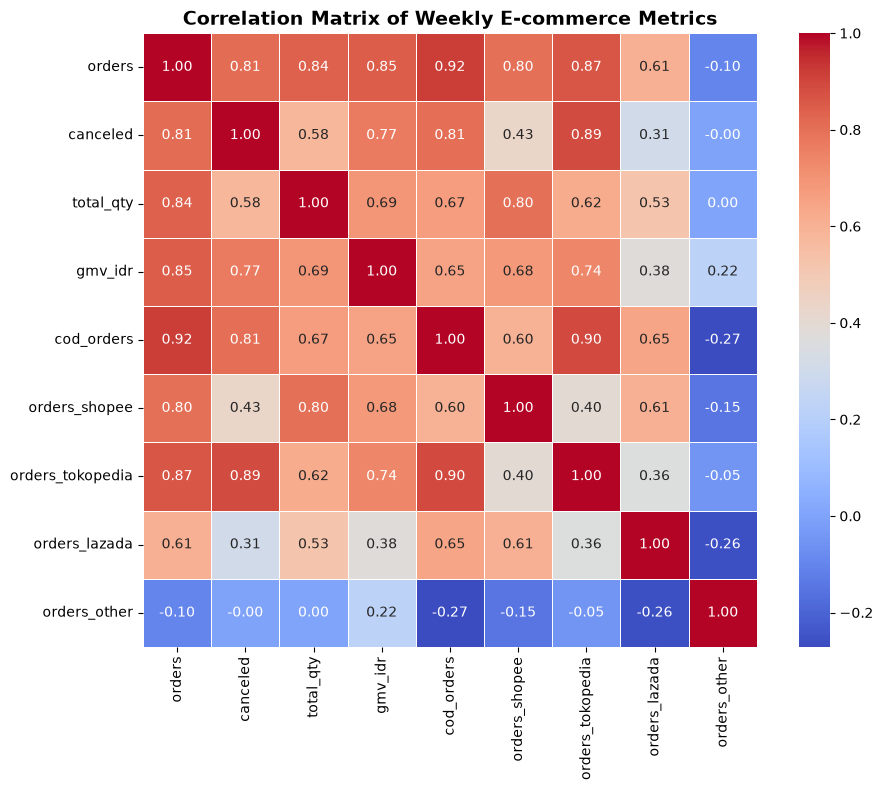

In [17]:
# Pearson Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=ax, linewidths=.5)
ax.set_title('Correlation Matrix of Weekly E-commerce Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('correlation_matrix.png', dpi=300)
# plt.close()

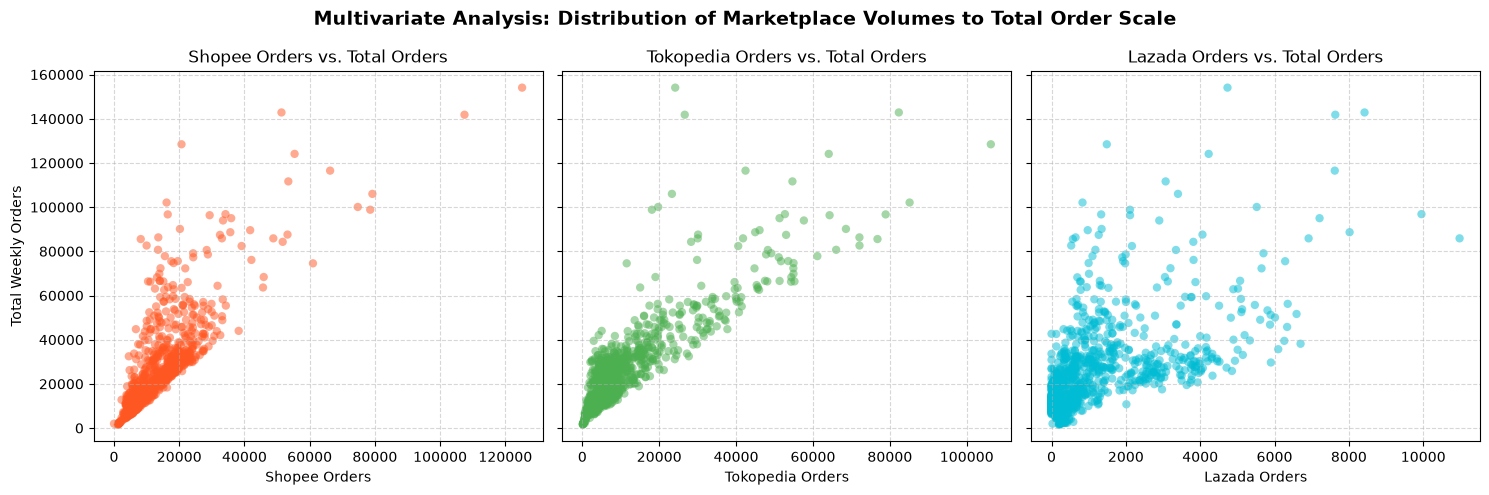

In [18]:
# Multivariate Channel Scale Grids
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Subplot A: Shopee vs Total
axs[0].scatter(weekly_features['orders_shopee'], weekly_features['orders'], alpha=0.5, color='#FF5722', edgecolors='none')
axs[0].set_title('Shopee Orders vs. Total Orders')
axs[0].set_xlabel('Shopee Orders')
axs[0].set_ylabel('Total Weekly Orders')
axs[0].grid(True, linestyle='--', alpha=0.5)

# Subplot B: Tokopedia vs Total
axs[1].scatter(weekly_features['orders_tokopedia'], weekly_features['orders'], alpha=0.5, color='#4CAF50', edgecolors='none')
axs[1].set_title('Tokopedia Orders vs. Total Orders')
axs[1].set_xlabel('Tokopedia Orders')
axs[1].grid(True, linestyle='--', alpha=0.5)

# Subplot C: Lazada vs Total
axs[2].scatter(weekly_features['orders_lazada'], weekly_features['orders'], alpha=0.5, color='#00BCD4', edgecolors='none')
axs[2].set_title('Lazada Orders vs. Total Orders')
axs[2].set_xlabel('Lazada Orders')
axs[2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Multivariate Analysis: Distribution of Marketplace Volumes to Total Order Scale', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('marketplace_vs_total_multivariate.png', dpi=300)
# plt.close()

Outlier & Anomaly Detection

In [19]:
weekly_features['week_start'] = pd.to_datetime(weekly_features['week_start'])
# Compute Statistical Bounds (IQR Rule) per Company
anomalies = []
for company in weekly_features['company'].unique():
    comp_data = weekly_features[weekly_features['company'] == company].copy()
    q1 = comp_data['orders'].quantile(0.25)
    q3 = comp_data['orders'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Flag points breaking standard limits
    comp_data['is_anomaly'] = (comp_data['orders'] < lower_bound) | (comp_data['orders'] > upper_bound)
    anomalies.append(comp_data)

weekly_anomalies = pd.concat(anomalies)

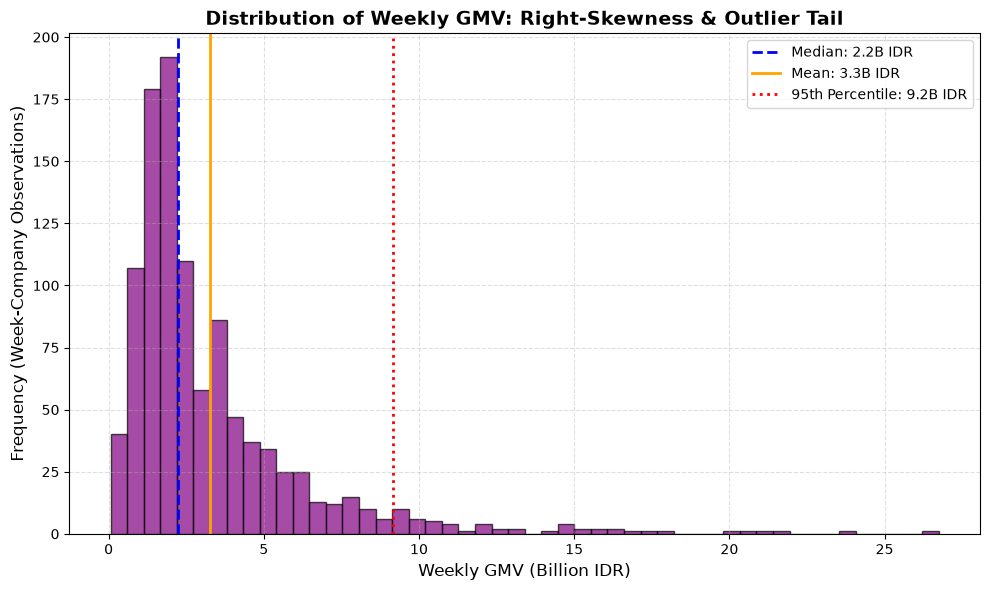

In [22]:
# Global Distribution Skewness (Outlier Long-Tail)
fig, ax = plt.subplots(figsize=(10, 6))
# Convert values into Billions for clean presentation
ax.hist(weekly_features['gmv_idr'] / 1e9, bins=50, color='purple', edgecolor='black', alpha=0.7)

# Draw indicator baselines
ax.axvline(weekly_features['gmv_idr'].median() / 1e9, color='blue', linestyle='--', linewidth=2, 
           label=f"Median: {weekly_features['gmv_idr'].median()/1e9:.1f}B IDR")
ax.axvline(weekly_features['gmv_idr'].mean() / 1e9, color='orange', linestyle='-', linewidth=2, 
           label=f"Mean: {weekly_features['gmv_idr'].mean()/1e9:.1f}B IDR")

p95 = weekly_features['gmv_idr'].quantile(0.95) / 1e9
ax.axvline(p95, color='red', linestyle=':', linewidth=2, label=f"95th Percentile: {p95:.1f}B IDR")

ax.set_title('Distribution of Weekly GMV: Right-Skewness & Outlier Tail', fontsize=14, fontweight='bold')
ax.set_xlabel('Weekly GMV (Billion IDR)', fontsize=12)
ax.set_ylabel('Frequency (Week-Company Observations)', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
# plt.savefig('gmv_outlier_distribution.png', dpi=300)
# plt.close()

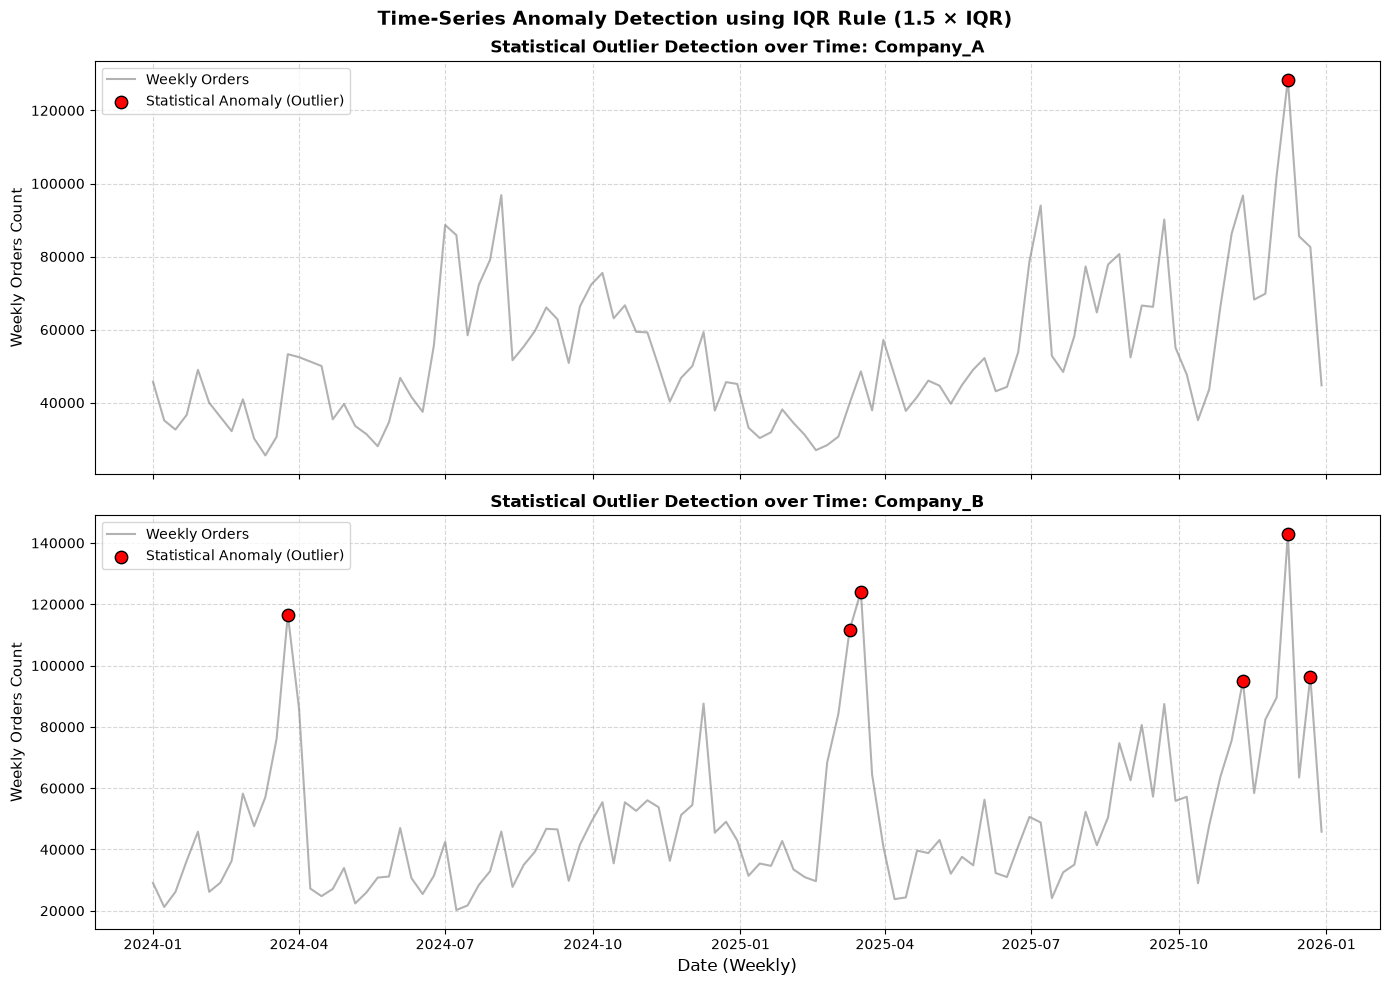

In [23]:
# Time-Series Anomaly Detection (Company_A & Company_B)
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for idx, company in enumerate(['Company_A', 'Company_B']):
    comp_data = weekly_anomalies[weekly_anomalies['company'] == company].sort_values('week_start')
    
    # Baseline normal line
    axs[idx].plot(comp_data['week_start'], comp_data['orders'], color='gray', alpha=0.6, label='Weekly Orders')
    
    # Overlay anomalies
    anom_points = comp_data[comp_data['is_anomaly']]
    axs[idx].scatter(anom_points['week_start'], anom_points['orders'], color='red', s=80, 
                     edgecolors='black', zorder=5, label='Statistical Anomaly (Outlier)')
    
    axs[idx].set_title(f'Statistical Outlier Detection over Time: {company}', fontsize=12, fontweight='bold')
    axs[idx].set_ylabel('Weekly Orders Count', fontsize=11)
    axs[idx].grid(True, linestyle='--', alpha=0.5)
    axs[idx].legend(loc='upper left')

axs[1].set_xlabel('Date (Weekly)', fontsize=12)
plt.suptitle('Time-Series Anomaly Detection using IQR Rule (1.5 × IQR)', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('time_series_anomalies.png', dpi=300)
# plt.close()